# Lab: Linear Regression

FINALLY! WELCOME TO YOUR FIRST TEXTBOOK LAB SON!

I am SO GLAD you made it here!

Let's get right into it (after you're done reviewing pandas, or course).

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm

Besides importing whole modules, it's also possible to import only a few items from a given module. This will **help keep the namespace clean**. We will use a few specific objects from the `statsmodels` package which we import here.

(These are things we already knew, but it's always worth hammering this stuff in.)

In [2]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

We will also use from functions written for the labs in this book in the `ISLP` package.

In [3]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

# Inspecting Objects and Namespaces

The function `dir()` provides a list of objects in a namespace.

In [4]:
dir()

['In',
 'MS',
 'Out',
 'VIF',
 '_',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_i',
 '_i1',
 '_i2',
 '_i3',
 '_i4',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'anova_lm',
 'exit',
 'get_ipython',
 'load_data',
 'np',
 'open',
 'pd',
 'poly',
 'quit',
 'sm',
 'subplots',
 'summarize']

This shows you everything that Python can find at the top level. There are certain objects like `__builtins__` that contain references to build-in functions like `print()`.

Every Python object has its own notion of namespace, also accessible with `dir()`. This will include both the attributes of the object as well as any methods associated with it. For instance, we see `sum` in the listing for an array.

In [5]:
A = np.array([3, 5, 11])
dir(A)

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_namespace__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__buffer__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',


This indicates that the object `A.sum` exists. In this case it's a method that can be used to compute the sum of the array `A` as can be seen by typing `A.sum()`.

In [6]:
A.sum()

np.int64(19)

# Simple Linear Regression

In this section we'll construct matrices (also called design matrices) using the `ModelSpec()` transform from `ISLP.models`.

We will use the `Boston` housing data ser, which is contained in the `ISLP` package. This dataset records `medv` (median house value) for 506 neighborhoods around Boston. We will build a regression model to predict `medv` using 13 predictors such as `rmvar` (average number of rooms per house), `age` (proportion of owner-occupied units built priot to 1940), and `lstat` (percent of households with low socioeconomic status). We will use `statsmodels` for this task, a Python package that implements several commonly used regression methods.

We have included a simple loading function `load_data()` in the `ISLP` package:

`medv` - Median house value

## Review of example predictors
* `rmvar` - Average number of rooms per house
* `age` - Proportion of owner-occupied units build prior to 1940
* `lstat` - Percent of households with low socioeconomic status

In [7]:
Boston = load_data("Boston")
Boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


We start by using the `sm.OLS()` function to fit a simple linear regression model. Our response will be `medv` and `lstat` will be the single predictor.

Put simply, we are trying to predict the `medv` (median house value) using `lstat` (percent of households with low socioeconomic status).

For this model, we can create the model matrix by hand.

In [8]:
X = pd.DataFrame({"intercept": np.ones(Boston.shape[0]),
                 "lstat": Boston["lstat"]})

X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


We extract the response, and fit the model.

In [9]:
y = Boston["medv"]
model = sm.OLS(y, X)
results = model.fit()

Note that `sm.OLS()` does not fit the model; it specifies the model, and then `model.fit()` does the actuall fitting.

Our `ISLP` function `summarize()` produces a simple table of the parameter estimates, their standard errors, t-statistics and p-values. The function takes a single argument, such as the object `results` returned here by the `fit` method, and returns such a summary.

In [10]:
summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


**Review of p-values and t-statistic**

**P-values** tell you how likely is it that random chance alone created this pattern in your data.

**T-statistics** measure how many standard errors away from 0 your estimate is. The bigger the absolute value of the t-statistic, the smaller the p-value. It shows you the signal-to-noise ratio. A big |t| means your estimated effect is large relative to the uncertainty around it. A small |t| means your effect might be real but you can't tell it apart from the noise.

**P>|t|** is just the p-value. It's the probability of getting a t-statistic whose absolute value is bigger. For example:

* P>|t| = 0.02 means "if the true effect were zero, there's only a 2% chance I'd see a t-statistic this extreme in either direction".

Before we describe other methods for working with fitted models, we outline a more useful and general framework for constructing a model matrix `X`.

# Using Transformations: Fit and Transform

Our model above has a single predictor, and constructing `X` was straightforward. In practice we often fit models with more than one predictor, typically selected from an array or data frame. We may wish to introduce transformations to the variables before fitting the model, specify interactions between variables, and expand some particular variables into sets of variables (such as polynomials). The `sklearn` package has a particular notion for this type of task: a **transform**. A **transform is an object that is created with some parameters as arguments**. the object has two main methods: `fit()` and `transform()`.

We provide a general approach for specifying models and constructing the model matrix through the transform `ModelSpec()` in the `ISLP` library. `ModelSpec()` (renames `MS()` in the preamble) creates a transform object, and then a pair of methods `transform()` and `fit()` are used to construct a corresponding model matrix.

We first describe this process for our simple regression model using a single predictor `lstat` in the `Boston` data frame, but will use it repeatedly in more complex tasks in this and other labs in this book. In our cas the transform is created by the expression `design = MS(['lstat])`.

The `fit()` method takes the original array and may do some initial computations on it, as specified in the transform object. For example, it may compute means and standard deviations for centering and scaling. The `transform()` method applies the fitted transformation to the array of data, and produces the model matrix.

In [11]:
design = MS(['lstat']) # Creates a transform object
print(design)
design = design.fit(Boston)
print(X.head(4))
X = design.transform(Boston)
X[:4]

ModelSpec(terms=['lstat'])
   intercept  lstat
0        1.0   4.98
1        1.0   9.14
2        1.0   4.03
3        1.0   2.94


,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In this simple case, the `fit()` method does very little; it simply checks that the variable `lstat` specified in `design` exists in `Boston`.

Then `transform()` constructs the model matrix with two columns: an `intercept` and the variable `lstat`.

These two operations can be combined with the `fit_transform()` method.

In [12]:
design = MS(["lstat"])
X = design.fit_transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


Note that, as in the previous code chunk when the two steps were done separately, the `design` object is changed as a result of the `fit()` operation. The power of this pipeline will become clearer when we fit more complex models that involve interactions and transformations.

Let's return to out fitted regression model. The object `results` has several methods that can be used for inference. We already presented a function `summarize()` for showing the essentials of the fit. For a full and somewhat exhaustive summary of the fit, we can use the `summary()` method.

In [13]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Tue, 09 Sep 2025   Prob (F-statistic):           5.08e-88
Time:                        10:35:23   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The fitted coefficients can also be retrieved as the `params` attribute of `results`.

In [14]:
results.params

intercept    34.553841
lstat        -0.950049
dtype: float64

The `get_prediction()` method can be used to obtain predictions, and produce confidence intervals and prediction intervals for the prediction `medv` for given values of `lstat`.

We first create a new data frame, in this case containing only the variable `lstat`, with the values for this variable at which we wish to make predictions. We then use the `transform()` method of `design` to create the corresponding model matrix.

In [15]:
new_df = pd.DataFrame({"lstat": [5, 10, 15]})
newX = design.transform(new_df)
newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


Next we compute the predictions at `newX`, and view them by extracting the `predicted_mean` attribute.

In [16]:
new_predictions = results.get_prediction(newX)
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

If you're confused, don't be. This is stupid simple. You're just testing out predictions using new data points and seeing what happens.

We can then produce confidence intervals for the predicted values.

**Note**: `alpha` is the confidence interval (in this case, 95%).

In [17]:
# These show the range where the true mean house value likely falls
new_predictions.conf_int(alpha=0.05)

array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

Prediction intervals are computing by setting `obs=True`:

In [18]:
# These show where individual house values might fall.
new_predictions.conf_int(obs=True, alpha=0.05)

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

So, to summarize, the confidence interval is the range that depicts the likely average for the given input of all houses with that income criteria, while the prediction interval is the range that depicts the likely range for individual houses for the given income criteria.

For instance, the 95% confidence interval associated with an `lstat` value of 10 is (24.47, 25.63), and the 95% prediction interval is (12.82, 37.28). As expected, the confidence and prediction intervals are centered around the same point (a predicted value of 25.05 for `medv` when `lstat` equals 10). but the latter are substantially wider.

Next we will plot `medv` and `lstat` using `DataFrame.plot.scatter()`, and wish to add the regression line to the resulting plot.

# Defining Functions

While there is a function within the `ISLP` package that add a line to an existing plot, we take this opportunity to define our first function to do to.

In [19]:
def abline(ax, b, m):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim)

A few things are illustrated above. First, we see the syntax for defining a function: `def funcname(...)`. The function has arguments `ax, b, m` where `ax` is an axis object for an existing plot, `b` is the intercept and `m` is the slope of the desired line. Other plotting options can be passed on to `ax.plot` by including additional optional arguments as follows:

In [20]:
def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

The addition of `*args` allows any number of non-named arguments to `abline`, while `*kwargs` allows any number of named arguments (such as `linewidth=3`) to `abline`. In our function, we pass these arguments verbatim to `ax.plot` above.

Let's use our new function to add this regression line to a plot of `modev` vs. `lstat`.

/var/folders/k9/p3wlytts06gdw_th38jfgf3h0000gn/T/ipykernel_64802/2622660773.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[0], # Slope
/var/folders/k9/p3wlytts06gdw_th38jfgf3h0000gn/T/ipykernel_64802/2622660773.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[1], # Intercept


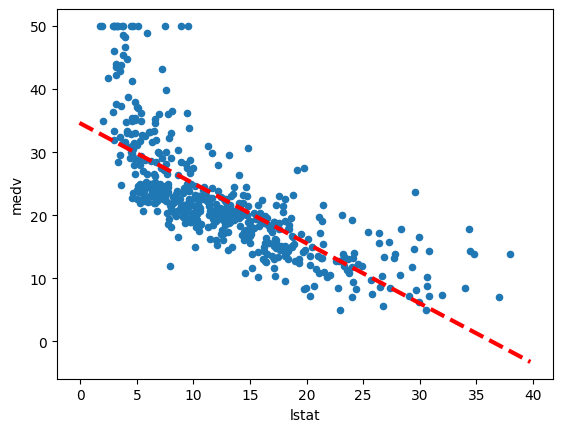

In [21]:
ax = Boston.plot.scatter('lstat', 'medv')
abline(ax,
       results.params[0], # Slope
       results.params[1], # Intercept
       'r--',
       linewidth=3)

Thus, the final call to `ax.plot()` is `ax.plot(xlim, ylim, 'r--', linewidth=3)`. We have used the argument `r--` to produce a red dashed line, and added an argument to make it a width of 3. There is some evidence for non-linearity in the relationship between `lstat` and `medv`. We will explore this issue later.

As mentioned above, there is an existing function to add a line to a plot -`ax.axline()`- but knowing how to write such functions empowers us to create more expressive displays.

Next, we examine some diagnostic plots. We can find fitted values and residuals of the fit as attributes of the `results` object. Various influence measures describing the regression model are computed with the `get_influence()` method. As we will not use the `fig` component returned as the first value from `subplots()`, we simply capture the second returned value in `ax` below.

Here's the residual plot for ya.

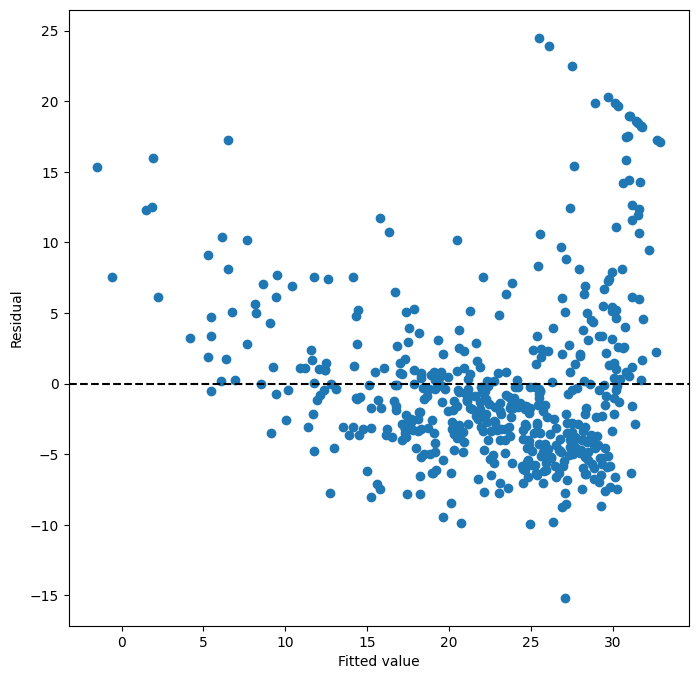

In [22]:
# Just to show what this is doing
ax = subplots(figsize=(8,8))[1] # (8,8) sets the dimensions to 8 by 8 inches
ax.scatter(results.fittedvalues, results.resid)
ax.set_xlabel("Fitted value")
ax.set_ylabel("Residual")
ax.axhline(0, c="k", ls="--")

We add a horizontal line at 0 for reference using the `ax.axhline()` method, indicating it should be black `(c='k')` and have a dashed linestyle (`ls='--')`).

On the basis of the residual plot, there is some evidence of non-linearity. Leverage statistics can be computed for any number of predictors using the `hat_matrix_diag` attribute of the value returned by the `get_influence()` method.

np.int64(374)

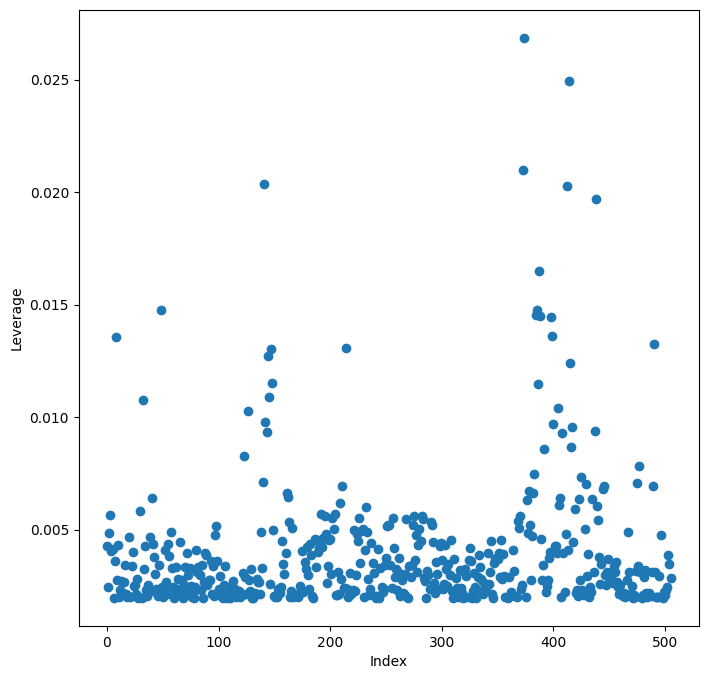

In [23]:
inf1 = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), inf1.hat_matrix_diag) # Computes leverage statistics
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(inf1.hat_matrix_diag)

The `np.argmax()` function identifies the index of the largest element of an array, optionally computed over an axis of the array. In this case, we maximized over the entire array to determine which observation has the largest leverage statistic.

# Multiple Linear Regression

In order to fit a multiple linear regression model using least squares, we again use the `ModelSpec()` transform to construct the required model matrix and response. The arguments to `ModelSpec()` can be quite general, but in this case a list of column names suffice. We consider a fit here with the two variables `lstat` and `age`.

In [24]:
y = Boston["medv"] # Declared the `y` variable again just as a reminder of what it is
X = MS(['lstat', 'age']).fit_transform(Boston)

model1 = sm.OLS(y, X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


Notice how we have compacted the first line into a succinct expression describing the construction of `X`.

The `Boston` data set contains 12 variables,

In [25]:
print(Boston.columns[:-1])

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')


And so it would be cumbersome to have to type all of these in order to perform a regression using all of the predictors. Instead, we can use the following short-hand:

In [26]:
terms = Boston.columns.drop('medv')
terms

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

We can now fit the model with all the variables in `terms` using the same model matrix builder.

In [27]:
X = MS(terms).fit_transform(Boston)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


What if we would like to perform a regression using all of the variables but one? For example, in the above regression output, `age` has a high p-value (I noticed that!). So we may wish to run a regression excluding this predictor. The following syntax results in a regression using all predictors except `age`.

In [28]:
minus_age = Boston.columns.drop(['medv', 'age'])
Xma = MS(minus_age).fit_transform(Boston)
model1 = sm.OLS(y, Xma)
summarize(model1.fit())

,coef,std err,t,P>|t|
intercept,41.5251,4.920,8.441,0.000
crim,-0.1214,0.033,-3.683,0.000
zn,0.0465,0.014,3.379,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8528,0.868,3.287,0.001
nox,-18.4851,3.714,-4.978,0.000
rm,3.6811,0.411,8.951,0.000
dis,-1.5068,0.193,-7.825,0.000
rad,0.2879,0.067,4.322,0.000
tax,-0.0127,0.004,-3.333,0.001


# Multivariate Goodness of Fit

We can access the individual components of `results` by name (`dir(results)` shows us what's available). Hence, `results.rsquared` gives us the R**2, and `np.sqrt(results.scale)` gives us the RSE.

Variance inflation factors are sometimes useful to assess the effect of collinearity in the model matrix of a regression model. We will compute the VIFs in our multiple regression fit, and use the opportunity to introduce the idea of *list comprehension*.

In [29]:
dir(results)

['HC0_se',
 'HC1_se',
 'HC2_se',
 'HC3_se',
 '_HCCM',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abat_diagonal',
 '_cache',
 '_data_attr',
 '_data_in_cache',
 '_get_robustcov_results',
 '_get_wald_nonlinear',
 '_is_nested',
 '_transform_predict_exog',
 '_use_t',
 '_wexog_singular_values',
 'aic',
 'bic',
 'bse',
 'centered_tss',
 'compare_f_test',
 'compare_lm_test',
 'compare_lr_test',
 'condition_number',
 'conf_int',
 'conf_int_el',
 'cov_HC0',
 'cov_HC1',
 'cov_HC2',
 'cov_HC3',
 'cov_kwds',
 'cov_params',
 'cov_type',
 'df_model',
 'df_resid',
 'diagn',
 'eigenvals',
 'el_test',
 'ess',
 'f_pval

## List Comprehension

List comprehensions are simple and powerful ways to form lists of Python objects. the language also supports dictionary and generator comprehension, though these are beyond our scope here. Let's look at an example. We compute the VIF for each of the variables in the model matrix `X`, using the function `variance_inflation_factor()`.

In [30]:
vals = [VIF(X, i)
        for i in range(1, X.shape[1])]
vif = pd.DataFrame({'vif': vals},
                   index=X.columns[1:])
vif

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


**As a reminder:**

VIF measures how much multicollinearity affects each predictor. It tells you how much the variance of a coefficient estimate inflates due to correlations with other predictors.
* VIF = 1: No correlation with other predictors (ideal)
* VIF = 2-5: Moderate correlation (usually acceptable)
* VIF > 5: High correlation (problematic)
* VIF > 10: Very high correlation (definitely remove or combine variables)

The function `VIF()` takes two arguments: a dataframe or array, and a variable column index. In the code above we call `VIF()` on the fly for all columns in `X`. We have excluded column 0 abpve (the intercept), which is not of interest. In this case, the VIFs are not that exciting.

The object `vals` above could have been constructed with the following for loop:

In [31]:
vals= []
for i in range(1, X.values.shape[1]):
    vals.append(VIF(X.values, i))

# Interaction Terms

**A quick reminder of what interaction terms are:**

## Interaction Terms

Interaction terms capture when the effect of one variable depends on the value of another variable.

In a basic linear model: `house_price = β₀ + β₁×rooms + β₂×location`

Each predictor has an independent, additive effect.

With an interaction term: `house_price = β₀ + β₁×rooms + β₂×location + β₃×(rooms × location)`

Now the effect of `rooms` changes depending on `location`. Maybe extra rooms add $10k to house value in suburbs but $50k in downtown areas.

It's easy to include interaction terms in a linear model using `ModelSpec()`. Including a tuple `("lstat", "age")` tells the model matrix builder to include an interaction term between `lstat` and `age`.

**Note:** These interaction terms were likely chosen based on domain knowledge (as far as I can tell).

In [32]:
X = MS(["lstat",
        "age",
        ("lstat", "age")]).fit_transform(Boston)

model2 = sm.OLS(y, X)
summarize(model2.fit())

,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


Remember how they said keep both terms if the interaction term is statistically significant even despite the other (in this case age) not being statistically significant?

# Non-linear Transformations of the Predictors

The model matrix builder can include terms beyond just column names and interactions. For instance, the `poly()` function supplied in `ILSP` specifies that columns representing polynomial functions of its first argument are added to the model matrix.

In [33]:
X = MS([poly('lstat', degree=2), 'age']).fit_transform(Boston)
model3 = sm.OLS(y, X)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


**Some notes/explanations**

`degree=2` creates polynomial terms up to the second degree for `lstat`.

Instead of just using `lstat`, it creates:
* `lstat` (degree 1)
* `lstat²` (degree 2)

So your model becomes: `medv = β₀ + β₁×lstat + β₂×lstat² + β₃×age`

The effectively zero --value associated with the quadratic term (the third row above) suggests that it leads to an improved mode,

By default, `poly()` creates a basis matrix for inclusion in the model matrix whose columns are *othogonal polynomials*, which are designed for stable least squared computations. Alternatively, had we included an argument `raw=True` in the above call to `poly()`, the basis matrix would consist simply of `lstat` and `lstat**2`. Since either of these bases represent quadratic polynomials, the fitted values would not change in this case, just the polynomial coefficients. Also by default, the columns created by `poly()` do not include an intercept column that's automatically added by `MS()`.

We use the `anova_lm()` function to further quantify the extent to which the quadratic fit is superior to the linear fit.

In [34]:
anova_lm(results1, results3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


## A quick review of the F-statistic

The F-statistic tests whether adding complexity to the model is worth it. It measures the **signal to noise** ratio. In other words, it asks "is the improvement from adding parameters real, or just random chance?"

* F = 1: The new parameters explain variation no better than noise.
* F > 1: The new parameters explain real patterns, not just noise.

In this case, `F` being equal to 177.28 means that the quadratic term explains variation 177 times better than random noise would.

**Note:** 

* `ssr` is the "sum of squared residuals".
* `df_diff` is "degrees of freedom difference" between consecutive models. This tells you how many additional parameters the more complex model is.

Here `results1` represents the linear submodel containing predictors `lstat` and `age`, while `results3` corresponds to the larger model above with a quadratic term in `lstat`. The `anova_lm()` function performs a hypothesis test comparing the two models. The null hypothesis is that the quadratic term in the bigger model is not needed, and the alternative hypothesis is that the bigger model is superior. Here the F-statistic is 177.28 and the associated p-value is zero. In this case the F-statistic is the square of the t-statistic for the quadratic term in the linear model summary for `results3`-a consequence of the fact that these nested models differ by one degree of freedom.

This provides very clear evidence that the quadratic polynomial in `lstat` improved the linear mode. This is not surprising, since earlier we saw evidence for non-linearity in the relationship between `medv` and `lstat`.

The function `anova_lm()` can take more than two nested models as input, in which case it compares every successive pair of models. That also explains why there are `NaN`s in the first row above, since there is no previous model with which to compare the first.

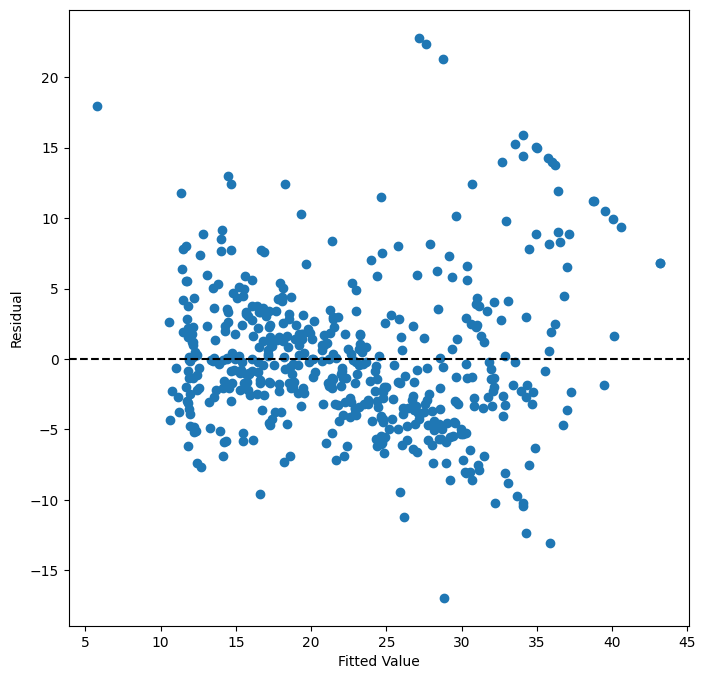

In [35]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results3.fittedvalues, results3.resid)
ax.set_xlabel("Fitted Value")
ax.set_ylabel("Residual")
ax.axhline(0, c="k", ls="--")

We see that when the quadratic term is included in the model, there's little discernible pattern in the residuals. In order to create a cubic or higher-degree polynomial fit, we can simply change the degree argument to `poly()`.

**Remember**, we don't want to see residual patterns in the model because patterns indicate that the model is missing something important. In other words, random residuals convey the fact that the model has accounted for everything and that all that's left by the residuals is random noise.

# Qualitative Predictors

Here we use the `Carseats` data, which is included in the `ISLP` package. We will attempt to predict `Sales` (child car seat sales) in 400 locations based on a number of predictors.

In [36]:
Carseats = load_data("Carseats")
Carseats.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

The `Carseats` data includes qualitative predictors such as `SholveLoc`: an indicator of the quality of the shelving location-that is, the space within a store in which the car seat is displayed. This takes on three possible values, `Bad`, `Medium`, and `Good`. 

Given a qualitative variable such as `ShelveLoc`, `ModelSpec()` generates dummy variables automatically. These variables are often referred to as *one-hot encoding* of the categorical feature. Their columns sum to one, so to avoid collinearity with an intercept, the first column is dropped. Below we fit a multiple regression model that includes some interaction terms.

In [37]:
allvars = list(Carseats.columns.drop("Sales"))
y = Carseats["Sales"]
final = allvars + [("Income", "Advertising"),
                   ("Price", "Age")]

X = MS(final).fit_transform(Carseats)
model = sm.OLS(y, X)
summarize(model.fit())

,coef,std err,t,P>|t|
intercept,6.5756,1.009,6.519,0.000
CompPrice,0.0929,0.004,22.567,0.000
Income,0.0109,0.003,4.183,0.000
Advertising,0.0702,0.023,3.107,0.002
Population,0.0002,0.000,0.433,0.665
Price,-0.1008,0.007,-13.549,0.000
ShelveLoc[Good],4.8487,0.153,31.724,0.000
ShelveLoc[Medium],1.9533,0.126,15.531,0.000
Age,-0.0579,0.016,-3.633,0.000
Education,-0.0209,0.020,-1.063,0.288


In the first line above, we made `allvars` a list, so that we could add the interaction terms two lines down. Our model-matrix builder has created a `ShelveLoc[Good]` dummy variable that takes on a value of 1 if the shelving location is good, and 0 otherwise. It has also created a `ShelveLoc[Medium]` dummy variable that equals 1 if the shelving location is medium, and 0 otherwise. **A bad shelving location corresponds to a zero for each of the two dummy variables**. The fact that the coefficient for `ShelveLoc[Good]` in the regression output is positive indicates that a good shelving location is associated with high sales (relative to a bad location). And `ShelveLoc[Medium]` has a smaller positive coefficient, indicating that a medium shelving location leads to higher sales than a bad shelving location, but lower sales than a good shelving location.